# IEAP – Python Series 03: Remarkable points in a signal

**Group:** Sarah DURAND · Zoé SAUGE · Shunan YIN

**GitHub repository:** https://github.com/sdurand875-spec/IEAP-python-series03

| Part | Content | Author | Source notebook |
|---|---|---|---|
| 2 | Functions: zero crossings, local maxima / minima, plots, unit tests | Sarah DURAND | [part2_functions](Section/part2_functions.ipynb) |
| 3 | Known signal (sum of two sine waves) and frequency computation | Zoé SAUGE | [part3_clean_signal](Section/part3_clean_signal.ipynb) |
| 4 | Noisy signal and low-pass filtering | Shunan YIN | [part4_noisy_signal](Section/part4_noisy_signal.ipynb) |

This main notebook **gathers the three parts** in the order of the assignment.
Each part was developed by its author in a separate notebook of the `Section/` folder, then merged here at the end of the project.

## Git workflow

- Each member worked on **their own branch** and **their own notebook**, so no file was edited by two people and there were no merge conflicts.
- Branches: `part2-functions`, `part3-CleanSignal`, `part-noisysignal`, plus branches for the README, the report and this main notebook.
- When a part was finished, its author opened a **pull request** to `main`, reviewed by another member before being merged.
- Function names and outputs were agreed on **before starting**, so that parts 3 and 4 could be written in parallel with part 2.
- In the separate notebooks, parts 3 and 4 load the previous parts with `%run`. In this main notebook, the parts are simply placed one after the other, so these `%run` lines are not needed.



# Part 2 – Functions to find and plot remarkable points

**Author:** Sarah DURAND

In this part, we break the linear code from the live coding session into small, reusable functions.
These functions are reused in parts 3 and 4.

**Naming conventions:**
- `i_...` : variables containing **indices** (addresses in the original array, usually computed with `np.where`)
- `find_...` : functions that **return indices**
- `plot_...` : functions that **plot without showing** (no `plt.show()`)
- `display_...` : functions that **plot and show** (end with `plt.show()`)

In [31]:
# Libraries used in this notebook
import numpy as np                  # arrays and numerical operations
import matplotlib.pyplot as plt     # plots

## 2.1. Reference signal

All functions are tested on the following hand-made reference signal.

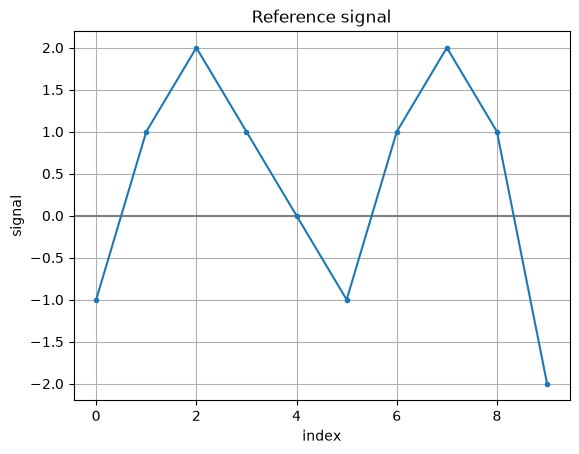

In [32]:
# Reference signal given in the assignment
index = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
signal = np.array([-1, 1, 2, 1, 0, -1, 1, 2, 1, -2])

# Quick plot to check the signal
plt.figure()
plt.axhline(y=0, color="gray")          # zero line
plt.plot(index, signal, ".-")           # signal with dots and line
plt.xlabel("index")
plt.ylabel("signal")
plt.title("Reference signal")
plt.grid(True)
plt.show()

### Teacher's code from the live coding session

The functions below were written during the live coding session. They are first copied as they are, then improved in section 2.2.

In [33]:
def find_zero_crossings_no_zeros(signs: np.ndarray):
    """Find zero crossings in a sign array without zeros"""
    diff = np.diff(signs)
    i_cross_pos = np.where(diff > 0)[0]
    i_cross_neg = np.where(diff < 0)[0]
    return i_cross_pos, i_cross_neg


def propagate_signs_over_zeros(signs: np.ndarray):
    """Propagate non-zero signs over zero positions in the sign array."""
    signs_no_zeros = signs.copy()
    mask = signs_no_zeros != 0
    idx = np.where(mask, np.arange(len(signs_no_zeros)), 0)
    idx = np.maximum.accumulate(idx)
    signs_no_zeros = signs_no_zeros[idx]
    if signs_no_zeros[0] == 0:
        i_first_nonzero = np.where(signs != 0)[0]
        if len(i_first_nonzero) > 0:
            signs_no_zeros[: i_first_nonzero[0]] = signs[i_first_nonzero[0]]
    return signs_no_zeros


def find_zero_crossings(s: np.ndarray):
    """Find zero crossings in a 1D signal array."""
    s = np.asarray(s)
    if s.ndim != 1:
        raise ValueError("Input must be a 1D array")
    signs = np.sign(s).astype(int)
    i_zeros = np.where(signs == 0)[0]
    if i_zeros.size > 0:
        signs_no_zeros = propagate_signs_over_zeros(signs)
    else:
        signs_no_zeros = signs
    return find_zero_crossings_no_zeros(signs_no_zeros)

In [34]:
def plot_signal(i: np.ndarray, s: np.ndarray, color: str = "blue"):
    """Plot the signal as function of time/index with grid and zero line"""
    plt.axhline(y=0, color="gray", linestyle="-")
    plt.plot(i, s, ".-", markersize=5, linewidth=0.25, color=color, label="signal")
    plt.ylabel("signal")
    plt.xlabel("index")


def plot_remarkable_points(t: np.ndarray, s: np.ndarray, format: str, label: str):
    """Plot remarkable points on a signal with format and label"""
    plt.plot(t, s, format, markersize=10, label=label)


def plot_positive_zero_crossings(i: np.ndarray, s: np.ndarray):
    """Plot positive zero crossings on a signal"""
    i_pos, _ = find_zero_crossings(s)
    plot_remarkable_points(i[i_pos], s[i_pos], "^r", "positive zero crossings")


def plot_negative_zero_crossings(i: np.ndarray, s: np.ndarray):
    """Plot negative zero crossings on a signal"""
    _, i_neg = find_zero_crossings(s)
    plot_remarkable_points(i[i_neg], s[i_neg], "vy", "negative zero crossings")


def plot_zero_crossings(i: np.ndarray, s: np.ndarray):
    """Plot all zero crossings on a signal"""
    plot_positive_zero_crossings(i, s)
    plot_negative_zero_crossings(i, s)


def display_signal_and_crossings(i: np.ndarray, s: np.ndarray):
    """Plot signal and zero crossings with legend outside the plot and grid"""
    plt.figure()
    plot_signal(i, s)
    plot_positive_zero_crossings(i, s)
    plot_negative_zero_crossings(i, s)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)
    plt.show()

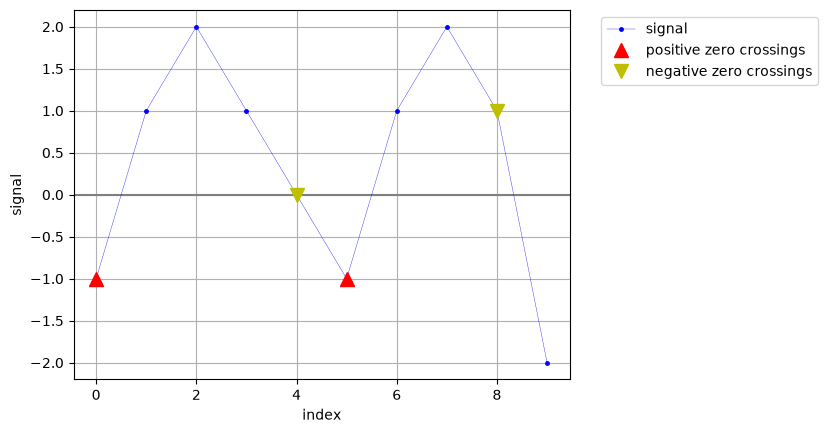

In [35]:
display_signal_and_crossings(index, signal)

## 2.2. Explain and improve the previous code

### Improved docstrings and comments

`find_zero_crossings` converts the signal into signs (-1, 0, +1), replaces the zeros by the previous non-zero sign (`propagate_signs_over_zeros`), then detects sign changes with `np.diff` (`find_zero_crossings_no_zeros`).
Each returned index is the **last sample before** the sign change.

In [36]:
def find_zero_crossings_no_zeros(signs: np.ndarray):
    """Find zero crossings in a sign array that contains no zeros.

    Parameters
    ----------
    signs : np.ndarray
        1D array containing only -1 and +1 values.

    Returns
    -------
    i_cross_pos : np.ndarray
        Indices k where the sign goes from -1 (at k) to +1 (at k+1).
    i_cross_neg : np.ndarray
        Indices k where the sign goes from +1 (at k) to -1 (at k+1).
    """
    # Difference between consecutive signs:
    #   +2 -> from -1 to +1 (positive crossing)
    #   -2 -> from +1 to -1 (negative crossing)
    #    0 -> no sign change
    diff = np.diff(signs)
    i_cross_pos = np.where(diff > 0)[0]   # indices of positive crossings
    i_cross_neg = np.where(diff < 0)[0]   # indices of negative crossings
    return i_cross_pos, i_cross_neg


def propagate_signs_over_zeros(signs: np.ndarray):
    """Replace each zero in a sign array by the last non-zero sign before it.

    Leading zeros (at the start of the array) take the first non-zero sign.
    Example: [0, 0, 1, 0, -1, 0] -> [1, 1, 1, 1, -1, -1]

    Parameters
    ----------
    signs : np.ndarray
        1D array of -1, 0 and +1 values.

    Returns
    -------
    signs_no_zeros : np.ndarray
        Same array with zeros replaced (only -1 and +1, unless the
        whole input is zero).
    """
    signs_no_zeros = signs.copy()   # copy so the input array is not modified

    # --- Step 1: replace each zero by the previous non-zero sign ---
    mask = signs_no_zeros != 0                                   # True where the sign is not zero
    idx = np.where(mask, np.arange(len(signs_no_zeros)), 0)     # own index if non-zero, 0 otherwise
    idx = np.maximum.accumulate(idx)                             # running max -> index of the last non-zero sign
    signs_no_zeros = signs_no_zeros[idx]                         # take the sign at that index

    # --- Step 2: handle leading zeros (no previous sign to copy) ---
    if signs_no_zeros[0] == 0:
        i_first_nonzero = np.where(signs != 0)[0]                # indices of all non-zero signs
        if len(i_first_nonzero) > 0:                             # at least one non-zero value exists
            # fill the beginning with the first non-zero sign
            signs_no_zeros[: i_first_nonzero[0]] = signs[i_first_nonzero[0]]

    return signs_no_zeros


def find_zero_crossings(s: np.ndarray):
    """Find the positive and negative zero crossings of a 1D signal.

    Zeros in the signal are handled: a sequence like [1, 0, -1] counts
    as ONE negative crossing.

    Parameters
    ----------
    s : np.ndarray (or list)
        1D signal.

    Returns
    -------
    i_cross_pos : np.ndarray
        Indices of positive zero crossings (signal goes up through 0).
    i_cross_neg : np.ndarray
        Indices of negative zero crossings (signal goes down through 0).
        Each index is the last sample before the sign change.

    Raises
    ------
    ValueError
        If the input is not a 1D array.
    """
    # --- Check the input ---
    s = np.asarray(s)                       # accept lists as well as arrays
    if s.ndim != 1:
        raise ValueError("Input must be a 1D array")

    # --- Convert the signal into signs (-1, 0, +1) ---
    signs = np.sign(s).astype(int)

    # --- Remove zeros only if there are some ---
    i_zeros = np.where(signs == 0)[0]
    if i_zeros.size > 0:
        signs_no_zeros = propagate_signs_over_zeros(signs)
    else:
        signs_no_zeros = signs

    # --- Find the sign changes ---
    return find_zero_crossings_no_zeros(signs_no_zeros)

In [37]:
def plot_signal(i: np.ndarray, s: np.ndarray, color: str = "blue"):
    """Plot a signal with a zero line (does not call plt.show()).

    Parameters
    ----------
    i : np.ndarray
        x-axis values (indices or time).
    s : np.ndarray
        Signal values, same length as i.
    color : str, optional
        Color of the signal (default "blue").
    """
    plt.axhline(y=0, color="gray", linestyle="-")   # zero line, drawn first so it stays under the signal
    plt.plot(i, s, ".-", markersize=5, linewidth=0.25, color=color, label="signal")
    plt.ylabel("signal")
    plt.xlabel("index")


def plot_remarkable_points(t: np.ndarray, s: np.ndarray, format: str, label: str):
    """Plot a set of remarkable points (does not call plt.show()).

    Parameters
    ----------
    t : np.ndarray
        x-axis values of the points.
    s : np.ndarray
        y-axis values of the points.
    format : str
        Matplotlib format string (e.g. "^r" = red triangle up).
    label : str
        Legend label.
    """
    plt.plot(t, s, format, markersize=10, label=label)


def plot_positive_zero_crossings(i: np.ndarray, s: np.ndarray):
    """Find and plot the positive zero crossings of s (red triangles up).

    Parameters
    ----------
    i : np.ndarray
        x-axis values (indices or time).
    s : np.ndarray
        Signal values.
    """
    i_pos, _ = find_zero_crossings(s)                                        # keep only positive crossings
    plot_remarkable_points(i[i_pos], s[i_pos], "^r", "positive zero crossings")


def plot_negative_zero_crossings(i: np.ndarray, s: np.ndarray):
    """Find and plot the negative zero crossings of s (yellow triangles down).

    Parameters
    ----------
    i : np.ndarray
        x-axis values (indices or time).
    s : np.ndarray
        Signal values.
    """
    _, i_neg = find_zero_crossings(s)                                        # keep only negative crossings
    plot_remarkable_points(i[i_neg], s[i_neg], "vy", "negative zero crossings")


def plot_zero_crossings(i: np.ndarray, s: np.ndarray):
    """Plot both positive and negative zero crossings of s.

    Parameters
    ----------
    i : np.ndarray
        x-axis values (indices or time).
    s : np.ndarray
        Signal values.
    """
    plot_positive_zero_crossings(i, s)
    plot_negative_zero_crossings(i, s)


def display_signal_and_crossings(i: np.ndarray, s: np.ndarray):
    """Create a figure with the signal and its zero crossings, then show it.

    Parameters
    ----------
    i : np.ndarray
        x-axis values (indices or time).
    s : np.ndarray
        Signal values.
    """
    plt.figure()                                            # new figure
    plot_signal(i, s)
    plot_zero_crossings(i, s)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")  # legend outside the plot
    plt.grid(True)
    plt.show()

The code behaviour is unchanged (only docstrings and comments were added), so the plot below must be identical to the previous one: this checks that nothing was broken.

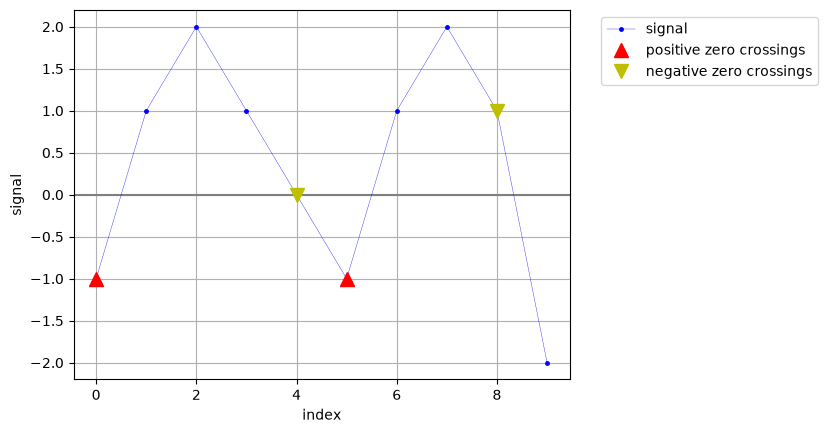

Help on function find_zero_crossings in module __main__:

find_zero_crossings(s: np.ndarray)
    Find the positive and negative zero crossings of a 1D signal.

    Zeros in the signal are handled: a sequence like [1, 0, -1] counts
    as ONE negative crossing.

    Parameters
    ----------
    s : np.ndarray (or list)
        1D signal.

    Returns
    -------
    i_cross_pos : np.ndarray
        Indices of positive zero crossings (signal goes up through 0).
    i_cross_neg : np.ndarray
        Indices of negative zero crossings (signal goes down through 0).
        Each index is the last sample before the sign change.

    Raises
    ------
    ValueError
        If the input is not a 1D array.



In [38]:
# Same result as before -> the improvements did not break the code
display_signal_and_crossings(index, signal)

# The improved docstring is now available with help()
help(find_zero_crossings)

### Role of the unit tests

A **unit test** checks that a function returns the **expected result** for a given input.
Each `assert` compares the output of `find_zero_crossings` with the result we expect: if they differ, an `AssertionError` is raised and we immediately know that the function is wrong.

Unit tests are useful to:
- **check that the function is correct**, including in tricky cases (zeros in the signal, zeros at the start or the end, etc.);
- **detect regressions**: if we modify the function later, re-running the tests tells us whether we broke something;
- **document the expected behaviour**: each test is a concrete example of what the function should return.

The teacher's tests below mainly cover signals **containing zeros**.

In [39]:
def test_find_zero_crossings():
    """Unit tests for find_zero_crossings function (teacher's tests)."""
    s = np.array([-1, 1, -1, 1, -1])
    # expected     +  -   +  -
    i_pos, i_neg = find_zero_crossings(s)
    assert np.array_equal(i_pos, np.array([0, 2]))
    assert np.array_equal(i_neg, np.array([1, 3]))

    s = np.array([-1, 0, 0, 1, 0, -1])
    # expected            +     -
    i_pos, i_neg = find_zero_crossings(s)
    assert np.array_equal(i_pos, np.array([2]))
    assert np.array_equal(i_neg, np.array([4]))

    s = np.array([0, 0, 0, 1, 0, 0])
    # expected    no crossings
    i_pos, i_neg = find_zero_crossings(s)
    assert np.array_equal(i_pos, np.array([]))
    assert np.array_equal(i_neg, np.array([]))

    s = np.array([0, 0, 1, 0, -1, 0])
    # expected             -
    i_pos, i_neg = find_zero_crossings(s)
    assert np.array_equal(i_pos, np.array([]))
    assert np.array_equal(i_neg, np.array([3]))

    s = np.array([0, 1, 0, 0, -1, 0])
    # expected             -
    i_pos, i_neg = find_zero_crossings(s)
    assert np.array_equal(i_pos, np.array([]))
    assert np.array_equal(i_neg, np.array([3]))

    s = np.array([1, 0, 0, -1, 0, 0])
    # expected          -
    i_pos, i_neg = find_zero_crossings(s)
    assert np.array_equal(i_pos, np.array([]))
    assert np.array_equal(i_neg, np.array([2]))


# Run the tests
test_find_zero_crossings()
print("All teacher's tests passed.")

All teacher's tests passed.


### Additional test cases

To cover **all possible scenarios**, we add tests for:

| Scenario | Example | Expected |
|---|---|---|
| Reference signal | `[-1, 1, 2, 1, 0, -1, 1, 2, 1, -2]` | pos `[0, 5]`, neg `[4, 8]` |
| One positive crossing | `[-1, 1]` | pos `[0]` |
| One negative crossing | `[1, -1]` | neg `[0]` |
| Always positive / always negative | `[1, 2, 3]`, `[-3, -2, -1]` | none |
| Only zeros | `[0, 0, 0]` | none |
| Signal touches zero without crossing | `[1, 0, 1]`, `[-1, 0, 0, -1]` | none |
| Zeros at the start | `[0, 0, -1, 1]` | pos `[2]` |
| Zeros at the end | `[1, -1, 0, 0]` | neg `[0]` |
| Decimal values | `[-0.5, 0.3, -0.1]` | pos `[0]`, neg `[1]` |
| Single value | `[5]` | none |
| Python list instead of array | `[2, -2, 2]` | pos `[1]`, neg `[0]` |
| 2D input (invalid) | `[[1, -1], [1, -1]]` | `ValueError` |

In [40]:
def check(s, expected_pos, expected_neg):
    """Helper: check that find_zero_crossings(s) returns the expected indices."""
    i_pos, i_neg = find_zero_crossings(s)
    assert np.array_equal(i_pos, np.array(expected_pos)), f"pos error for {s}: got {i_pos}"
    assert np.array_equal(i_neg, np.array(expected_neg)), f"neg error for {s}: got {i_neg}"


def test_find_zero_crossings_additional():
    """Additional unit tests to cover all scenarios."""
    # Reference signal of the assignment
    check([-1, 1, 2, 1, 0, -1, 1, 2, 1, -2], [0, 5], [4, 8])

    # Single crossings
    check([-1, 1], [0], [])
    check([1, -1], [], [0])

    # No crossing: always positive, always negative, only zeros
    check([1, 2, 3], [], [])
    check([-3, -2, -1], [], [])
    check([0, 0, 0], [], [])

    # The signal touches zero but does not cross it
    check([1, 0, 1], [], [])
    check([-1, 0, 0, -1], [], [])

    # Zeros at the start / at the end of the signal
    check([0, 0, -1, 1], [2], [])
    check([1, -1, 0, 0], [], [0])

    # Decimal values
    check([-0.5, 0.3, -0.1], [0], [1])

    # Signal with a single value
    check([5], [], [])

    # Python list instead of a numpy array
    check([2, -2, 2], [1], [0])

    # Invalid input: 2D array must raise a ValueError
    try:
        find_zero_crossings(np.array([[1, -1], [1, -1]]))
        raise AssertionError("A 2D input should raise a ValueError")
    except ValueError:
        pass   # expected behaviour


# Run the additional tests
test_find_zero_crossings_additional()
print("All additional tests passed.")

All additional tests passed.


## 2.3. Find the local maxima and minima

Local maxima and minima are the points where the **first derivative crosses zero**:
- a **local maximum** is where the derivative goes from **positive to negative** (negative zero crossing of the derivative);
- a **local minimum** is where the derivative goes from **negative to positive** (positive zero crossing of the derivative).

We approximate the derivative with `np.diff`, then reuse `find_zero_crossings` on it.
Since `np.diff` has one element less than the signal, we add **+1** to get back to the indices of the original signal.

In [41]:
def find_local_extrema(s: np.ndarray):
    """Find the local maxima and minima of a 1D signal.

    Parameters
    ----------
    s : np.ndarray (or list)
        1D signal.

    Returns
    -------
    i_local_max : np.ndarray
        Indices of the local maxima in s.
    i_local_min : np.ndarray
        Indices of the local minima in s.
    """
    s = np.asarray(s)                       # accept lists as well as arrays
    ds = np.diff(s)                         # approximate first derivative (length n-1)

    # Zero crossings of the derivative
    i_pos, i_neg = find_zero_crossings(ds)

    # +1 to go from derivative indices back to signal indices
    i_local_max = i_neg + 1                 # derivative: + -> -  => maximum
    i_local_min = i_pos + 1                 # derivative: - -> +  => minimum
    return i_local_max, i_local_min

In [42]:
def test_find_local_extrema():
    """Unit tests for find_local_extrema."""
    # Reference signal: maxima at 2 and 7, minimum at 5
    i_max, i_min = find_local_extrema([-1, 1, 2, 1, 0, -1, 1, 2, 1, -2])
    assert np.array_equal(i_max, [2, 7])
    assert np.array_equal(i_min, [5])

    # Monotonic signal: no extremum
    i_max, i_min = find_local_extrema([1, 2, 3])
    assert i_max.size == 0 and i_min.size == 0

    # Single minimum
    i_max, i_min = find_local_extrema([3, 1, 2])
    assert np.array_equal(i_min, [1]) and i_max.size == 0

    # Alternating signal: maxima at 1 and 3, minimum at 2
    i_max, i_min = find_local_extrema([1, 2, 1, 2, 1])
    assert np.array_equal(i_max, [1, 3])
    assert np.array_equal(i_min, [2])

    # Constant signal: no extremum
    i_max, i_min = find_local_extrema([0, 0, 0])
    assert i_max.size == 0 and i_min.size == 0


test_find_local_extrema()
print("All local extrema tests passed.")

All local extrema tests passed.


In [43]:
def plot_local_maxima(i: np.ndarray, s: np.ndarray):
    """Find and plot the local maxima of s (red stars).

    Parameters
    ----------
    i : np.ndarray
        x-axis values (indices or time).
    s : np.ndarray
        Signal values.
    """
    i_local_max, _ = find_local_extrema(s)
    plot_remarkable_points(i[i_local_max], s[i_local_max], "*r", "local maxima")


def plot_local_minima(i: np.ndarray, s: np.ndarray):
    """Find and plot the local minima of s (magenta stars).

    Parameters
    ----------
    i : np.ndarray
        x-axis values (indices or time).
    s : np.ndarray
        Signal values.
    """
    _, i_local_min = find_local_extrema(s)
    plot_remarkable_points(i[i_local_min], s[i_local_min], "*m", "local minima")


def plot_local_extrema(i: np.ndarray, s: np.ndarray):
    """Plot both local maxima and minima of s."""
    plot_local_maxima(i, s)
    plot_local_minima(i, s)


def display_signal_and_extrema(i: np.ndarray, s: np.ndarray):
    """Create a figure with the signal and its local extrema, then show it.

    Parameters
    ----------
    i : np.ndarray
        x-axis values (indices or time).
    s : np.ndarray
        Signal values.
    """
    plt.figure()
    plot_signal(i, s)
    plot_local_extrema(i, s)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")   # legend outside the plot
    plt.grid(True)
    plt.show()


def display_signal_and_remarkable_points(i: np.ndarray, s: np.ndarray, title: str = ""):
    """Create a figure with the signal, its zero crossings AND its local extrema, then show it.

    Used in parts 3 and 4 to plot all remarkable points at once.

    Parameters
    ----------
    i : np.ndarray
        x-axis values (indices or time).
    s : np.ndarray
        Signal values.
    title : str, optional
        Title of the figure.
    """
    plt.figure()
    plot_signal(i, s)
    plot_zero_crossings(i, s)
    plot_local_extrema(i, s)
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)
    plt.show()

# Part 3: Clean Signal & Frequency Analysis
**Author:** Zoé Sauge

## 3.1. Create the signal and plot it
We define the sampling frequency (`FS = 100 Hz`) and create the time vector `t` ranging from 0 to 2 seconds. Then, we generate the clean signal `s` as a combination of two sine waves (`s1` and `s2`), matching the reference figures.

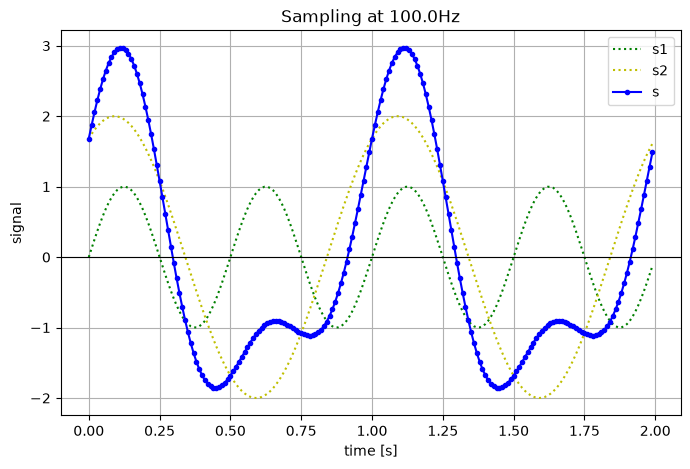

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# Define sampling frequency
FS = 100.0
t = np.arange(0, 2, 1 / FS)
s1 = np.sin(2 * np.pi * 2 * t)
s2 = 2 * np.sin(2 * np.pi * 1 * t + 1)
s = s1 + s2

# Plot the signals as shown in instruction 3.1
plt.figure(figsize=(8, 5))
plt.plot(t, s1, 'g:', label='s1')
plt.plot(t, s2, 'y:', label='s2')
plt.plot(t, s, 'b.-', label='s')
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('time [s]')
plt.ylabel('signal')
plt.title('Sampling at 100.0Hz')
plt.grid(True)
plt.legend()
plt.show()

## 3.2. Plot the remarkable points
Using the functions defined in Part 2, we identify and plot the local maxima, local minima, and zero crossings.

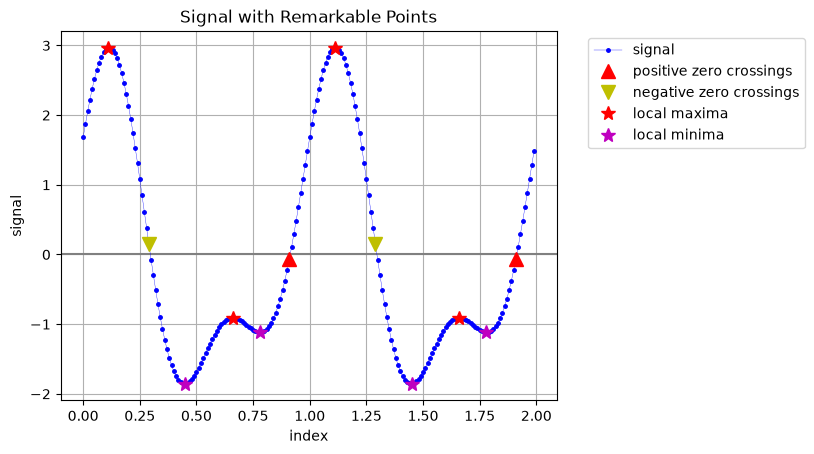

In [45]:
# Call the display function from Part 2 to show the signal and its remarkable points
display_signal_and_remarkable_points(t, s, title="Signal with Remarkable Points")

## 3.3. Use the remarkable points to find the frequency of the signal
We compute the frequency of the signal by analyzing the time intervals (periods) between consecutive zero-crossing points sharing the same slope.

In [46]:
def compute_frequency_from_zero_crossings(t: np.ndarray, s: np.ndarray) -> dict:
    """Compute the period and frequency of a signal from its zero crossings.

    Zero crossings with the same slope are one period apart.

    Parameters
    ----------
    t : np.ndarray
        Time vector (s), regularly sampled.
    s : np.ndarray
        Signal values.

    Returns
    -------
    dict
        Deltas between zero crossings (samples), periods (s) and frequency (Hz).
    """
    fs = 1 / (t[1] - t[0])                       # sampling frequency computed from t
    i_pos, i_neg = find_zero_crossings(s)        # function from part 2

    # Number of samples between consecutive crossings with the same slope
    delta_pos = np.diff(i_pos)
    delta_neg = np.diff(i_neg)

    # Convert samples to seconds
    period_pos = np.mean(delta_pos) / fs
    period_neg = np.mean(delta_neg) / fs
    period = (period_pos + period_neg) / 2

    return {
        "delta_zero_crossing_pos (samples)": delta_pos,
        "delta_zero_crossing_neg (samples)": delta_neg,
        "signal_period_pos (s)": period_pos,
        "signal_period_neg (s)": period_neg,
        "signal_period (s)": period,
        "signal_frequency (Hz)": 1 / period,
    }


def print_frequency_info(info: dict, title: str = ""):
    """Print the frequency information with keys aligned to the right."""
    if title:
        print(title)
    width = max(len(key) for key in info)        # length of the longest key
    for key, value in info.items():
        print(f"  {key:>{width}} : {value}")


frequency_info = compute_frequency_from_zero_crossings(t, s)
print_frequency_info(frequency_info, "Analysis of the clean signal:")

Analysis of the clean signal:
  delta_zero_crossing_pos (samples) : [100]
  delta_zero_crossing_neg (samples) : [100]
              signal_period_pos (s) : 1.0
              signal_period_neg (s) : 1.0
                  signal_period (s) : 1.0
              signal_frequency (Hz) : 1.0


# Part 4 – Analysis of a noisy signal

**Author:** Shunan YIN

We redo the remarkable points analysis on the signal of part 3 with added **white noise**, then remove the noise with a **low-pass filter**.

In [47]:
# scipy is only needed from part 4 (parts 2 and 3 are already loaded above)
from scipy.signal import butter, filtfilt

## 4.1. Create the noisy signal and plot it

We add **white noise** (uniform random values, generated with `np.random`) to the clean signal `s` of part 3.
The noise amplitude is **20 % of the peak-to-peak amplitude** of the signal. A fixed seed makes the result reproducible.

signal_peak_to_peak_amplitude =  4.822252617910321
noise_amplitude =  0.9644505235820642


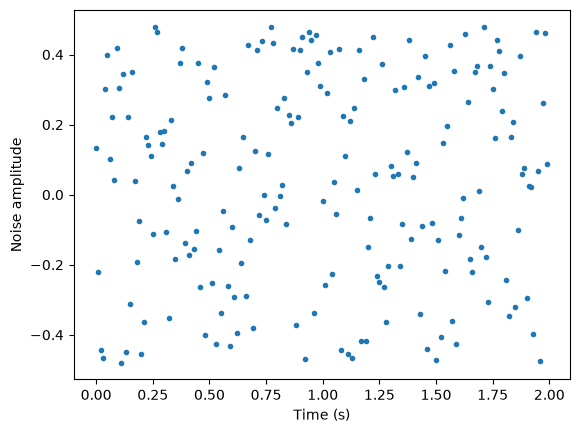

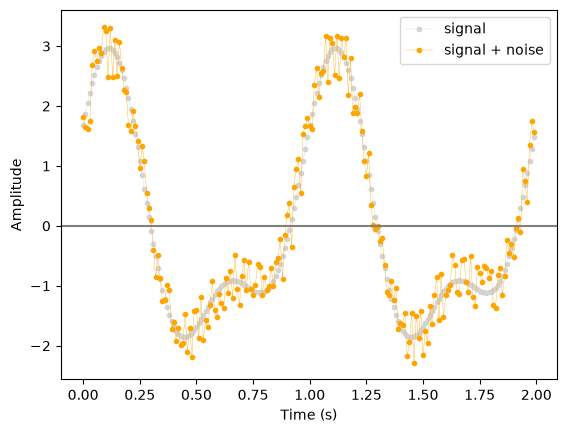

In [48]:
# Noise amplitude = 20 % of the peak-to-peak amplitude of the clean signal
signal_peak_to_peak_amplitude = np.ptp(s)
noise_amplitude = 0.2 * signal_peak_to_peak_amplitude
print("signal_peak_to_peak_amplitude = ", signal_peak_to_peak_amplitude)
print("noise_amplitude = ", noise_amplitude)

# White noise: uniform values between -noise_amplitude/2 and +noise_amplitude/2
rng = np.random.default_rng(seed=0)                  # fixed seed -> same noise every time
noise = rng.uniform(-noise_amplitude / 2, noise_amplitude / 2, size=len(t))
s_noisy = s + noise

# Plot the noise alone
plt.figure()
plt.plot(t, noise, ".")
plt.xlabel("Time (s)")
plt.ylabel("Noise amplitude")
plt.show()

# Plot the clean and noisy signals (dots + thin line, linewidth = 0.25)
plt.figure()
plt.plot(t, s, ".-", color="lightgray", linewidth=0.25, label="signal")
plt.plot(t, s_noisy, ".-", color="orange", linewidth=0.25, label="signal + noise")
plt.axhline(y=0, color="gray")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

## 4.2. Plot the remarkable points in the noisy signal

We reuse the functions of part 2. Because of the noise, the signal crosses zero **several times** around each real crossing, which creates **false remarkable points** and gives a **wrong frequency**.

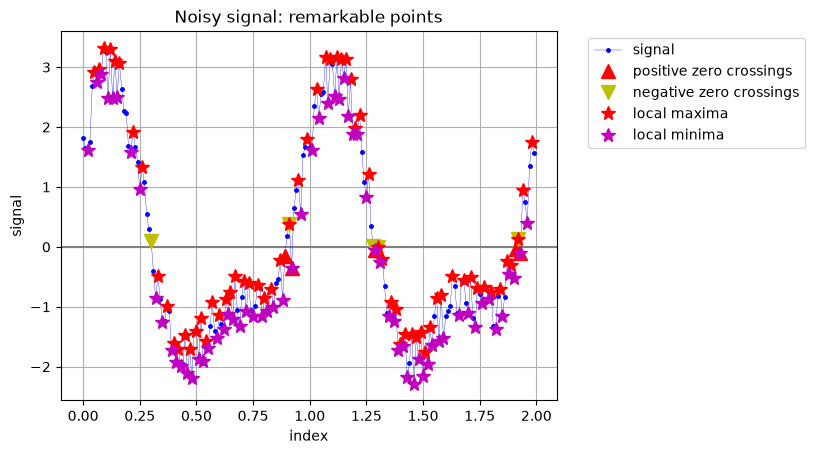

Analysis of the noisy signal:
  delta_zero_crossing_pos (samples) : [ 3 37 62  2]
  delta_zero_crossing_neg (samples) : [61 37  2 62]
              signal_period_pos (s) : 0.26
              signal_period_neg (s) : 0.405
                  signal_period (s) : 0.3325
              signal_frequency (Hz) : 3.007518796992481


In [49]:
# Remarkable points of the noisy signal (function from part 2)
display_signal_and_remarkable_points(t, s_noisy, title="Noisy signal: remarkable points")

# Frequency analysis (functions from part 3)
info_noisy = compute_frequency_from_zero_crossings(t, s_noisy)
print_frequency_info(info_noisy, "Analysis of the noisy signal:")

## 4.3. Low pass filter the noisy signal

We use a **Butterworth low-pass filter** (`butter`) with a cut-off frequency of **5 Hz**, applied forward and backward with `filtfilt` so that the filtered signal is **not shifted in time**.
The signal frequencies (1 and 2 Hz) are kept, while the faster noise is removed.

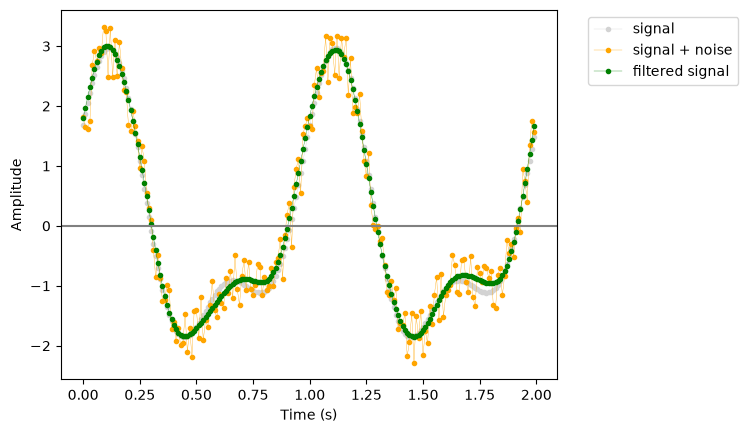

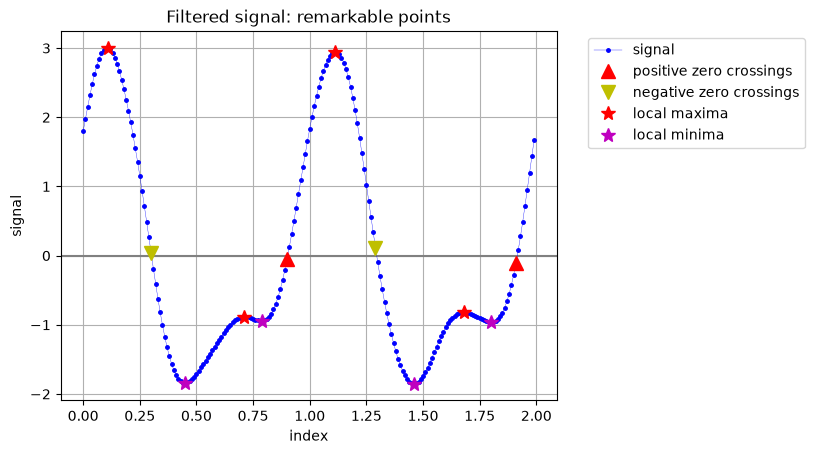

Analysis of noisy signal low pass filtered at 5 Hz:
  delta_zero_crossing_pos (samples) : [101]
  delta_zero_crossing_neg (samples) : [99]
              signal_period_pos (s) : 1.01
              signal_period_neg (s) : 0.99
                  signal_period (s) : 1.0
              signal_frequency (Hz) : 1.0


In [50]:
def low_pass_filter(s: np.ndarray, fs: float, cutoff: float = 5.0, order: int = 4) -> np.ndarray:
    """Apply a zero-phase Butterworth low-pass filter to a signal.

    Parameters
    ----------
    s : np.ndarray
        Signal to filter.
    fs : float
        Sampling frequency (Hz).
    cutoff : float, optional
        Cut-off frequency (Hz), default 5 Hz.
    order : int, optional
        Order of the filter, default 4.

    Returns
    -------
    np.ndarray
        Filtered signal, same length as s.
    """
    b, a = butter(order, cutoff, btype="low", fs=fs)   # filter coefficients
    return filtfilt(b, a, s)                            # forward + backward -> no time shift


s_filtered = low_pass_filter(s_noisy, FS, cutoff=5.0)

# Plot the clean, noisy and filtered signals
plt.figure()
plt.plot(t, s, ".-", color="lightgray", linewidth=0.25, label="signal")
plt.plot(t, s_noisy, ".-", color="orange", linewidth=0.25, label="signal + noise")
plt.plot(t, s_filtered, ".-", color="green", linewidth=0.25, label="filtered signal")
plt.axhline(y=0, color="gray")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

# Remarkable points and frequency of the filtered signal
display_signal_and_remarkable_points(t, s_filtered, title="Filtered signal: remarkable points")
info_filtered = compute_frequency_from_zero_crossings(t, s_filtered)
print_frequency_info(info_filtered, "Analysis of noisy signal low pass filtered at 5 Hz:")